# Normalization

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

input_root = "../preprocessed_data"   # we already processed images
output_root = "../normalized_data"    # new normalized version
os.makedirs(output_root, exist_ok=True)

for subset in ["Training", "Testing"]:
    in_dir = os.path.join(input_root, subset)
    out_dir = os.path.join(output_root, subset)
    os.makedirs(out_dir, exist_ok=True)

    for cls in os.listdir(in_dir):
        cls_in = os.path.join(in_dir, cls)
        cls_out = os.path.join(out_dir, cls)
        os.makedirs(cls_out, exist_ok=True)

        for file in tqdm(os.listdir(cls_in), desc=f"{subset}/{cls}"):
            if file.lower().endswith(('.png','.jpg','.jpeg')):
                img = cv2.imread(os.path.join(cls_in, file), cv2.IMREAD_GRAYSCALE)
                norm = img.astype(np.float32) / 255.0
                np.save(os.path.join(cls_out, file.replace('.png','.npy')), norm)


Testing/pituitary: 100%|█████████████████████████████████████████████████████████████| 300/300 [00:03<00:00, 91.81it/s]


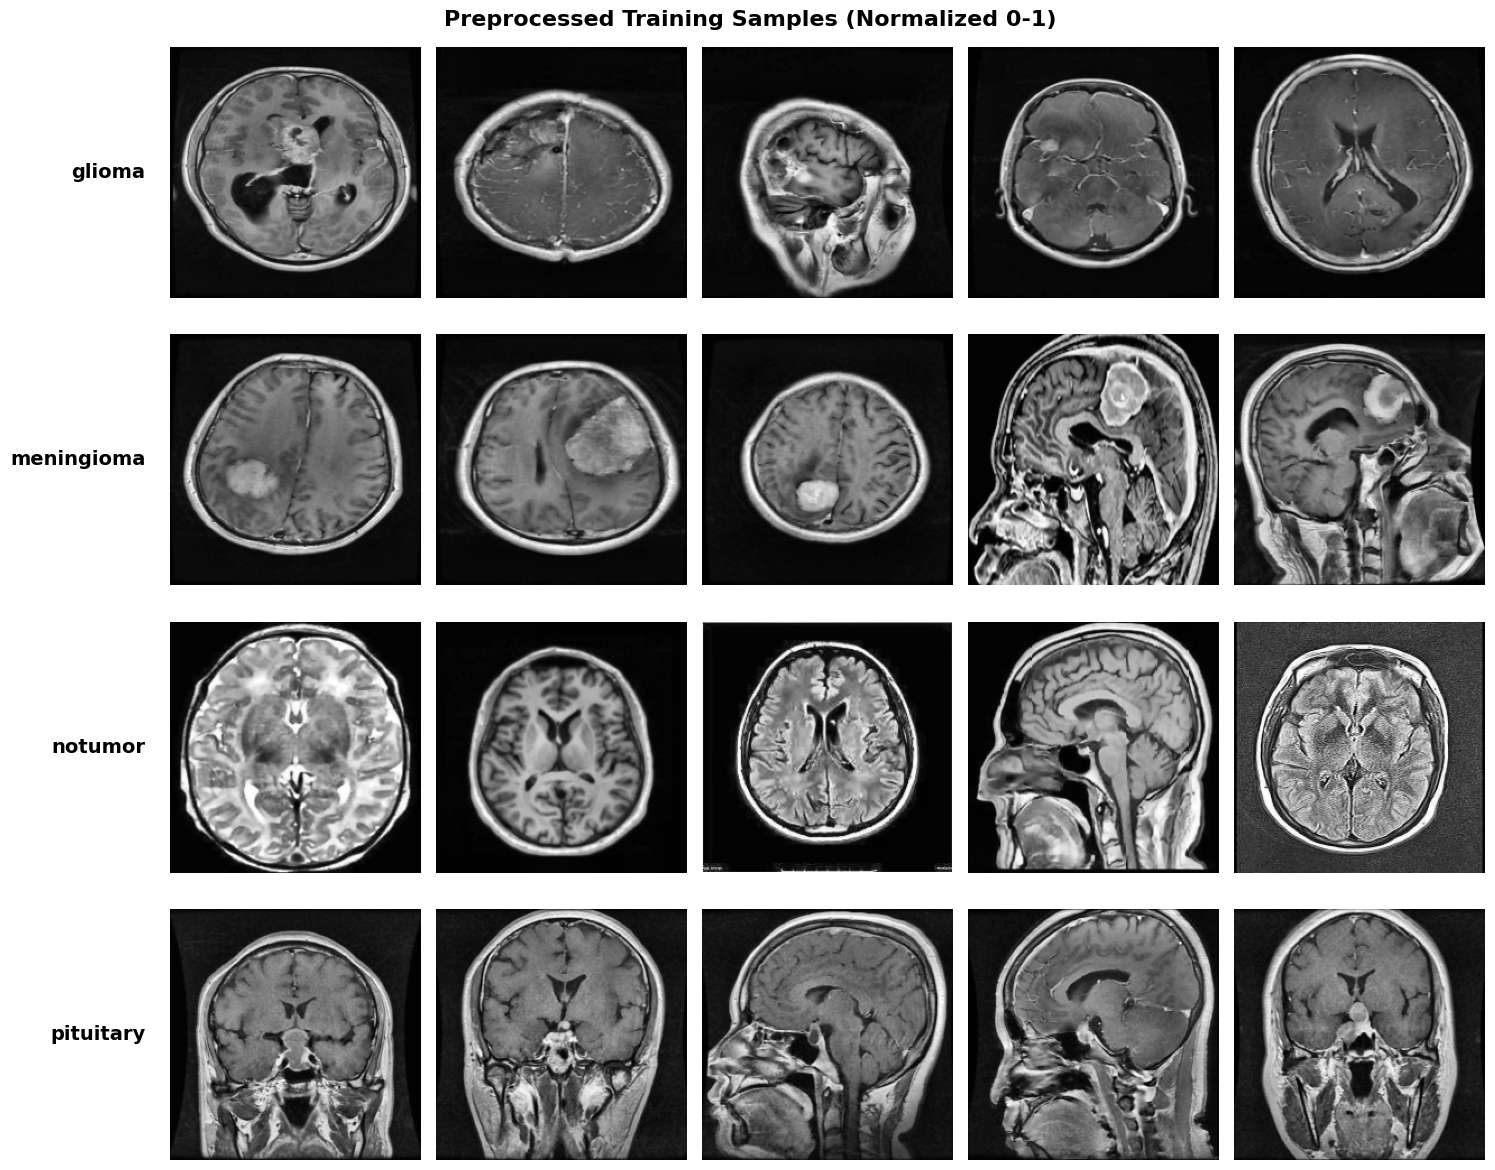

In [6]:
import matplotlib.pyplot as plt
import os
import numpy as np # <-- Added import for numpy.load()
import random
# NOTE: cv2 is not needed here since we are loading .npy files

def visualize_preprocessed_samples(preprocessed_path, samples_per_class=5):
    """Show some preprocessed images."""
    
    train_dir = os.path.join(preprocessed_path, "Training")
    # Using 'Training' and not 'train' here, match your directory structure.
    classes = sorted(os.listdir(train_dir))
    
    # Calculate figure size dynamically
    fig, axes = plt.subplots(len(classes), samples_per_class, 
                             figsize=(15, len(classes) * 3))
    
    # Ensure axes is always 2D even for single class/sample case
    if len(classes) == 1 and samples_per_class == 1:
        axes = np.array([[axes]])
    elif len(classes) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, cls in enumerate(classes):
        cls_dir = os.path.join(train_dir, cls)
        # Ensure we only try to list directories that exist
        if not os.path.isdir(cls_dir):
            continue
            
        files = [f for f in os.listdir(cls_dir) 
                 if f.lower().endswith(('.png.npy', '.jpg.npy', '.jpeg.npy'))]
        
        # Random sample
        sampled = random.sample(files, min(samples_per_class, len(files)))
        
        for j, filename in enumerate(sampled):
            img_path = os.path.join(cls_dir, filename)
            
            # --- FIX IS HERE ---
            # Load the NumPy array directly from the .npy file
            try:
                img = np.load(img_path) 
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue

            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')
            
            if j == 0:
                axes[i, j].text(-0.1, 0.5, cls,
                                 transform=axes[i, j].transAxes,
                                 fontsize=14, fontweight='bold',
                                 va='center', ha='right')
    
    plt.suptitle("Preprocessed Training Samples (Normalized 0-1)", 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize
visualize_preprocessed_samples(output_root, samples_per_class=5)